In [1]:
import os
import glob
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random
import math
from tqdm import tqdm

C:\Users\Admin\AppData\Local\Temp\ipykernel_14648\3203889954.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_counts.sort_values('Count', ascending=False), x='Count', y='Class', palette='viridis')


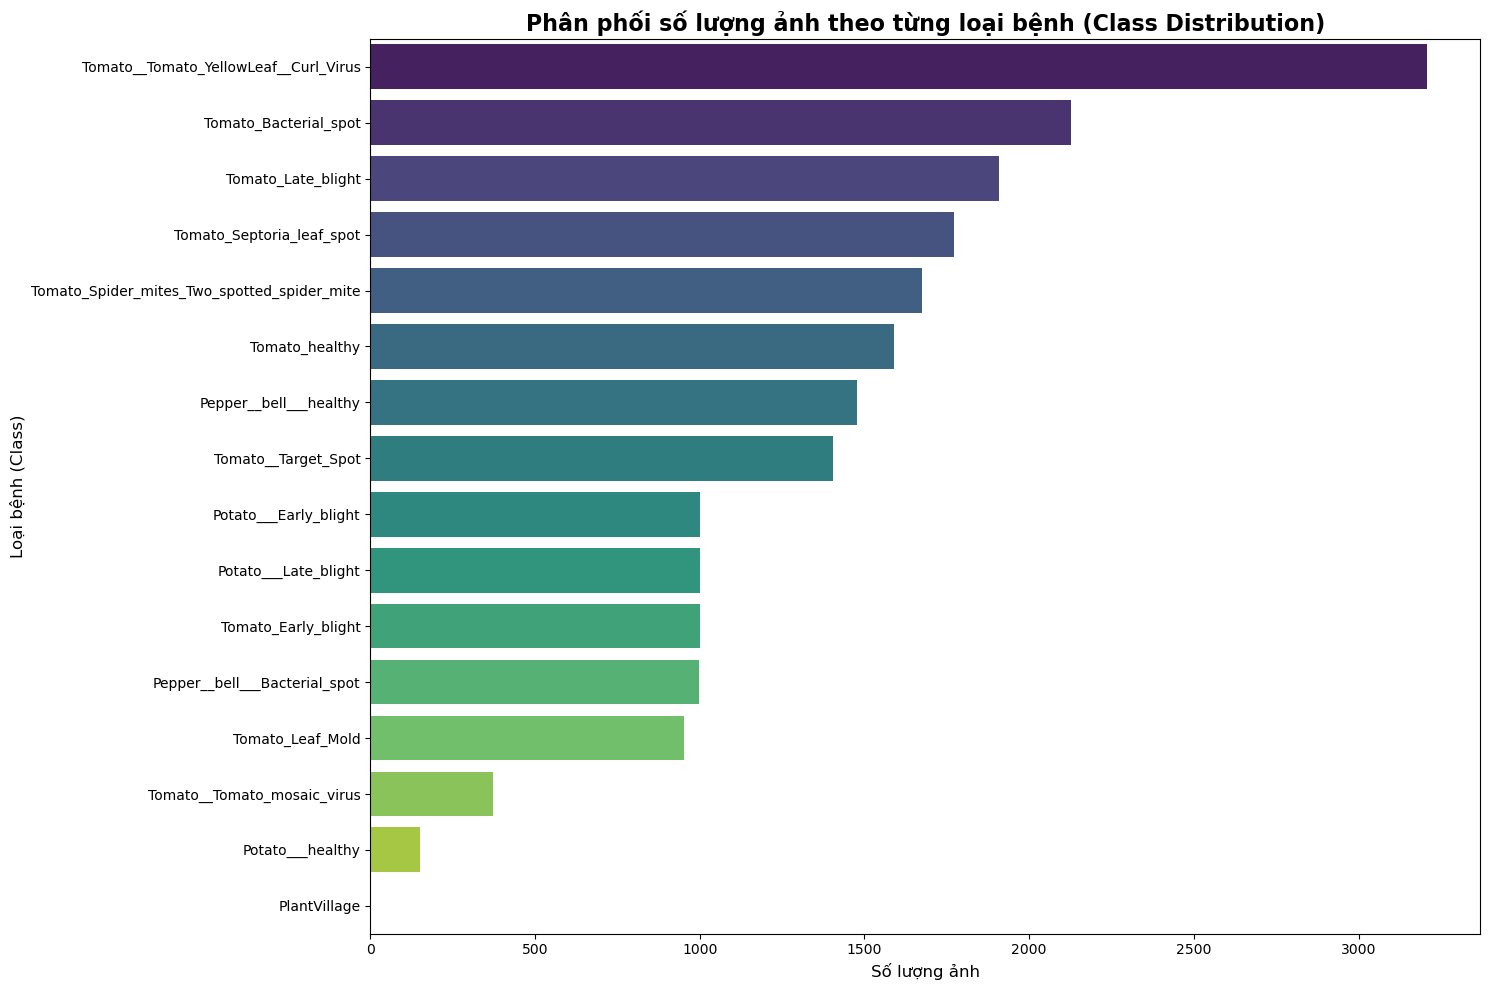

Tổng số phân lớp (Classes): 16
Tổng số ảnh trong dataset: 20638
Class có nhiều ảnh nhất: Tomato__Tomato_YellowLeaf__Curl_Virus (3208 ảnh)
Class có ít ảnh nhất: PlantVillage (0 ảnh)


In [3]:
data_dir = 'PlantVillage' 

# Lấy danh sách các class (tên thư mục)
classes = [d for d in os.listdir(data_dir) if os.path.isdir(os.path.join(data_dir, d))]
classes.sort()

# Đếm số lượng ảnh trong mỗi class
class_counts = []
for c in classes:
    path = os.path.join(data_dir, c)
    num_images = len(glob.glob(os.path.join(path, '*.*')))
    class_counts.append(num_images)

# Tạo DataFrame để dễ thao tác
df_counts = pd.DataFrame({'Class': classes, 'Count': class_counts})

# --- VẼ BIỂU ĐỒ PHÂN PHỐI ---
plt.figure(figsize=(15, 10))
sns.barplot(data=df_counts.sort_values('Count', ascending=False), x='Count', y='Class', palette='viridis')
plt.title('Phân phối số lượng ảnh theo từng loại bệnh (Class Distribution)', fontsize=16, fontweight='bold')
plt.xlabel('Số lượng ảnh', fontsize=12)
plt.ylabel('Loại bệnh (Class)', fontsize=12)
plt.tight_layout()
plt.show()

# In ra thống kê cơ bản
print(f"Tổng số phân lớp (Classes): {len(classes)}")
print(f"Tổng số ảnh trong dataset: {sum(class_counts)}")
print(f"Class có nhiều ảnh nhất: {df_counts.loc[df_counts['Count'].idxmax()]['Class']} ({df_counts['Count'].max()} ảnh)")
print(f"Class có ít ảnh nhất: {df_counts.loc[df_counts['Count'].idxmin()]['Class']} ({df_counts['Count'].min()} ảnh)")

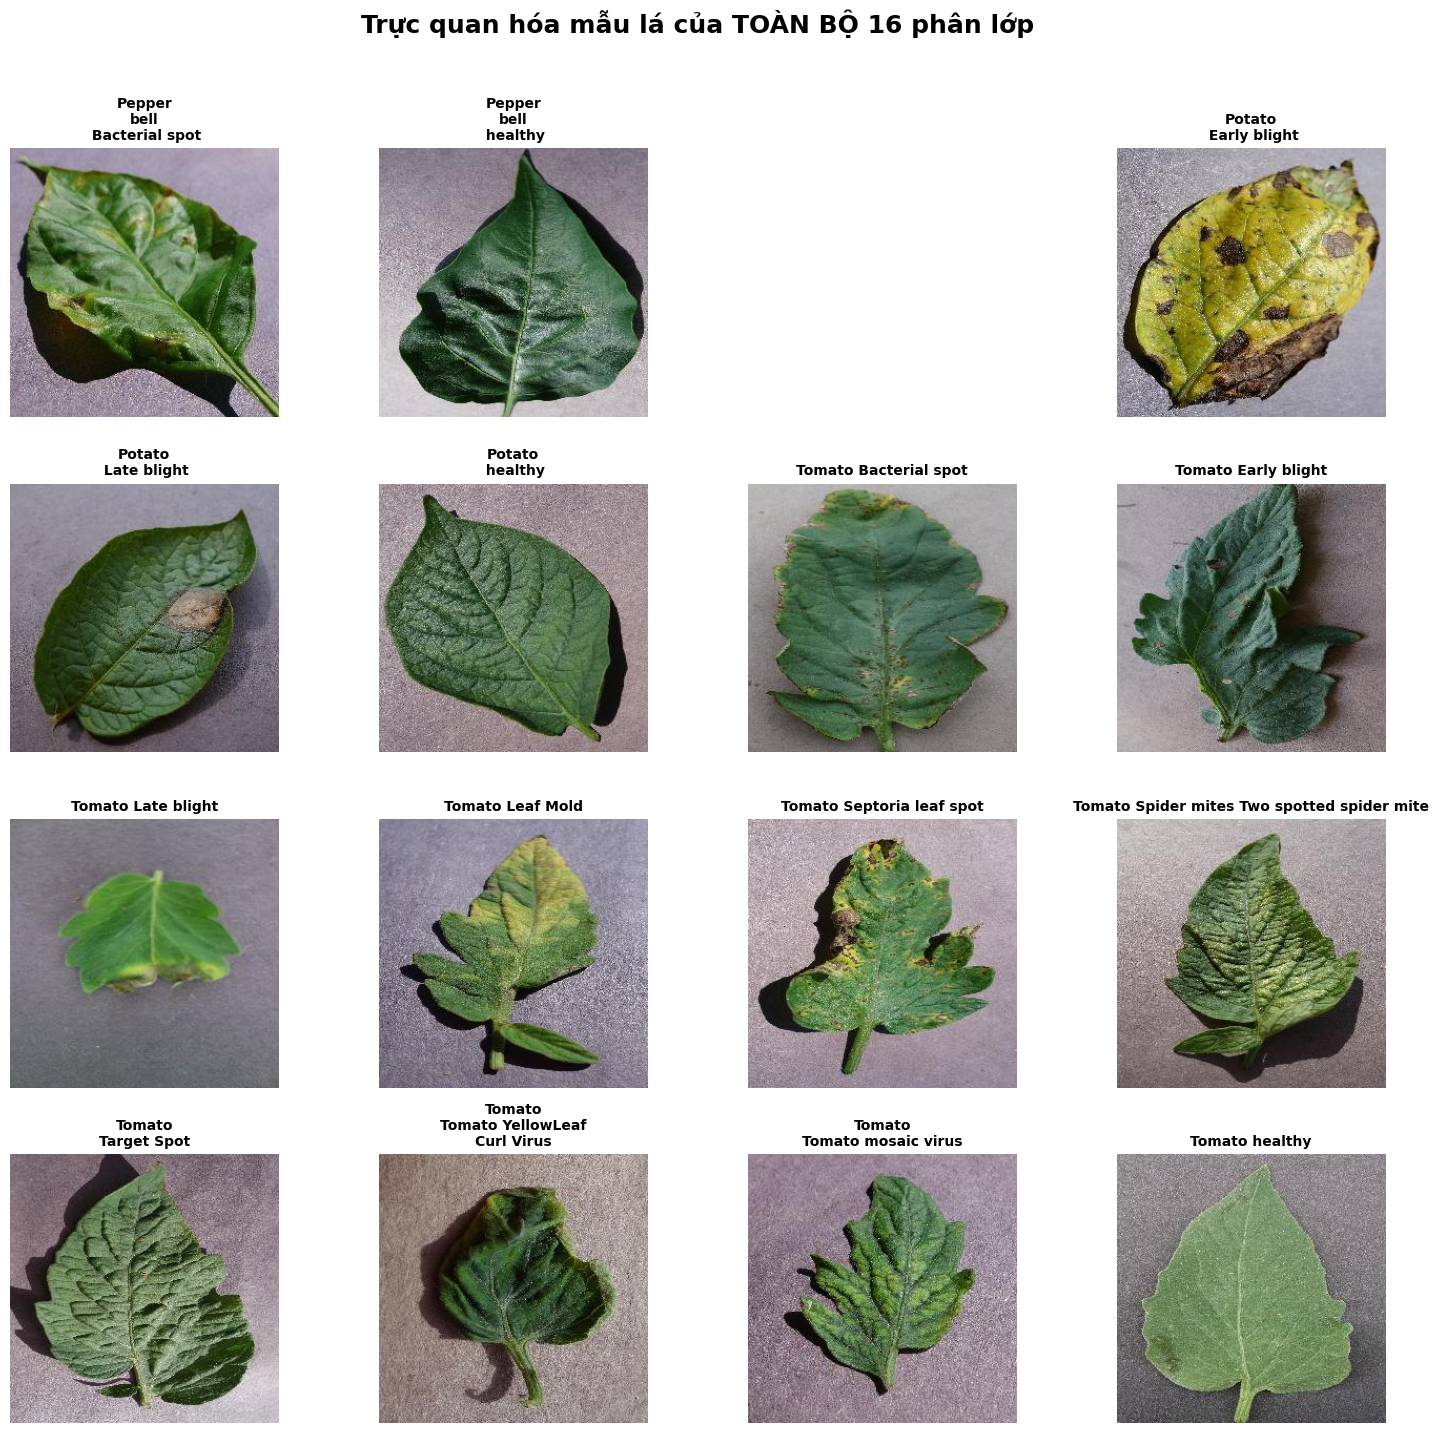

In [4]:
# Lấy TOÀN BỘ class thay vì chọn ngẫu nhiên
sample_classes = classes 
num_classes = len(sample_classes)

# Tự động tính toán lưới ảnh (Mặc định cho 4 cột, tự động tính số hàng)
cols = 4
rows = math.ceil(num_classes / cols)

# Điều chỉnh kích thước Figure tự động dài ra theo số hàng
plt.figure(figsize=(15, 3.5 * rows))

for i, c in enumerate(sample_classes):
    path = os.path.join(data_dir, c)
    
    # Lấy ngẫu nhiên 1 ảnh đại diện trong class này
    img_files = glob.glob(os.path.join(path, '*.*'))
    if not img_files: continue
    
    img_path = random.choice(img_files)
    img = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) 
    
    # Vẽ vào vị trí tương ứng trong lưới
    plt.subplot(rows, cols, i+1)
    plt.imshow(img_rgb)
    
    # Rút gọn tên class (xuống dòng nếu có dấu __) để chữ không bị đè lên nhau
    short_title = c.replace('__', '\n').replace('_', ' ')
    plt.title(short_title, fontsize=10, fontweight='bold')
    plt.axis('off')

plt.suptitle(f'Trực quan hóa mẫu lá của TOÀN BỘ {num_classes} phân lớp', fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

🚀 Đang bắt đầu phân tích toàn bộ 20638 ảnh...
Quá trình này có thể mất vài phút, vui lòng đợi nhé!


Đang xử lý ảnh: 100%|██████████| 20638/20638 [00:37<00:00, 553.49it/s] 


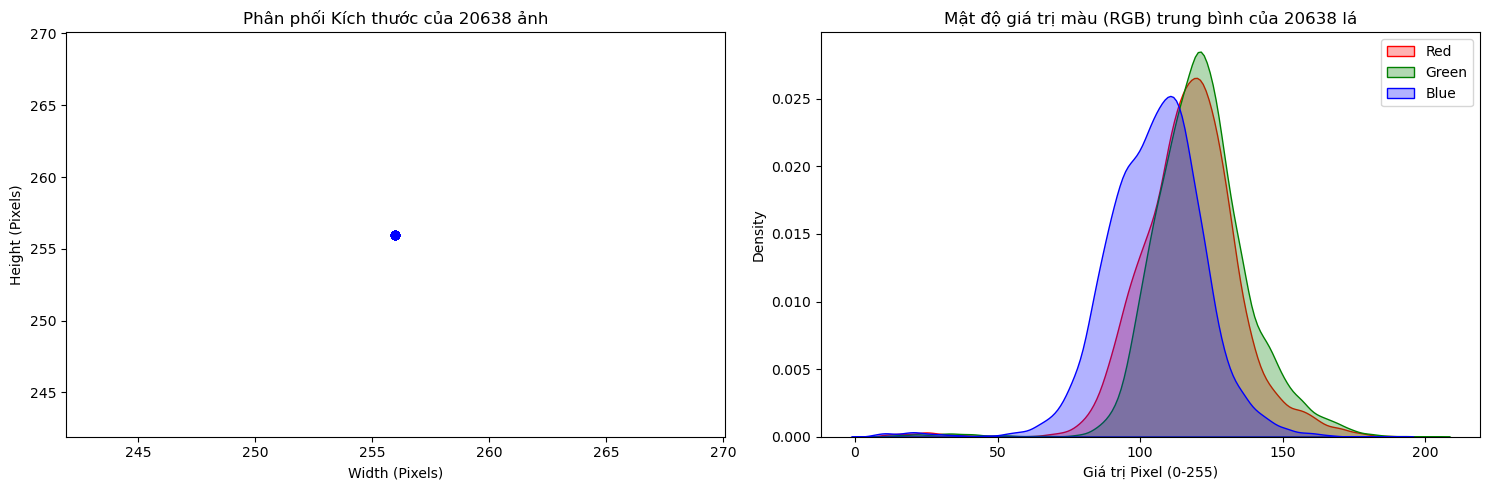

In [5]:
all_images = glob.glob(os.path.join(data_dir, '*/*.*'))

heights, widths = [], []
mean_r, mean_g, mean_b = [], [], []

print(f"🚀 Đang bắt đầu phân tích toàn bộ {len(all_images)} ảnh...")
print("Quá trình này có thể mất vài phút, vui lòng đợi nhé!")

for img_path in tqdm(all_images, desc="Đang xử lý ảnh"):
    img = cv2.imread(img_path)
    if img is None: continue
        
    # Ghi nhận kích thước ảnh
    h, w, _ = img.shape
    heights.append(h)
    widths.append(w)
    
    # Ghi nhận giá trị màu trung bình (R, G, B)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    mean_r.append(np.mean(img_rgb[:,:,0]))
    mean_g.append(np.mean(img_rgb[:,:,1]))
    mean_b.append(np.mean(img_rgb[:,:,2]))

# --- VẼ BIỂU ĐỒ KÍCH THƯỚC VÀ PHÂN PHỐI MÀU ---
fig, axs = plt.subplots(1, 2, figsize=(15, 5))

# 1. Phân phối độ phân giải ảnh (Scatter plot)
# Vì số lượng điểm quá lớn (hàng chục nghìn), ta giảm alpha xuống 0.1 để thấy rõ độ đậm đặc
axs[0].scatter(widths, heights, alpha=0.1, color='blue')
axs[0].set_title(f'Phân phối Kích thước của {len(heights)} ảnh')
axs[0].set_xlabel('Width (Pixels)')
axs[0].set_ylabel('Height (Pixels)')

# 2. Phân phối các kênh màu RGB (KDE plot)
sns.kdeplot(mean_r, color='red', label='Red', ax=axs[1], fill=True, alpha=0.3)
sns.kdeplot(mean_g, color='green', label='Green', ax=axs[1], fill=True, alpha=0.3)
sns.kdeplot(mean_b, color='blue', label='Blue', ax=axs[1], fill=True, alpha=0.3)
axs[1].set_title(f'Mật độ giá trị màu (RGB) trung bình của {len(heights)} lá')
axs[1].set_xlabel('Giá trị Pixel (0-255)')
axs[1].set_ylabel('Density')
axs[1].legend()

plt.tight_layout()
plt.show()

In [12]:
all_images = glob.glob(os.path.join(data_dir, '*/*.*'))

hues = []
textures = []
labels = []

print(f"🚀 Đang trích xuất đặc trưng HSV và Texture từ {len(all_images)} ảnh...")
for img_path in tqdm(all_images, desc="Processing"):
    img = cv2.imread(img_path)
    if img is None: continue
        
    # Tên class (thư mục cha)
    class_name = img_path.split(os.sep)[-2]
    # Rút gọn tên cho dễ nhìn trên biểu đồ
    short_class = class_name.split('___')[-1] if '___' in class_name else class_name
    
    # 1. Tính giá trị Hue (Sắc độ) trung bình
    img_hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    # Kênh H trong OpenCV có giá trị từ 0-179
    mean_hue = np.mean(img_hsv[:,:,0]) 
    
    # 2. Tính độ nhám / góc cạnh (Laplacian Variance)
    img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    texture_score = cv2.Laplacian(img_gray, cv2.CV_64F).var()
    
    hues.append(mean_hue)
    textures.append(texture_score)
    labels.append(short_class)

# Tạo DataFrame lưu vào bộ nhớ RAM
df_eda2 = pd.DataFrame({'Class': labels, 'Hue': hues, 'Texture': textures})
print("\n=> Rút trích hoàn tất! Dữ liệu đã sẵn sàng ở biến df_eda2 để vẽ biểu đồ.")

🚀 Đang trích xuất đặc trưng HSV và Texture từ 20638 ảnh...


Processing: 100%|██████████| 20638/20638 [00:34<00:00, 594.14it/s]


=> Rút trích hoàn tất! Dữ liệu đã sẵn sàng ở biến df_eda2 để vẽ biểu đồ.


C:\Users\Admin\AppData\Local\Temp\ipykernel_14648\2044140402.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_eda2, x='Class', y='Hue', palette='Set2')


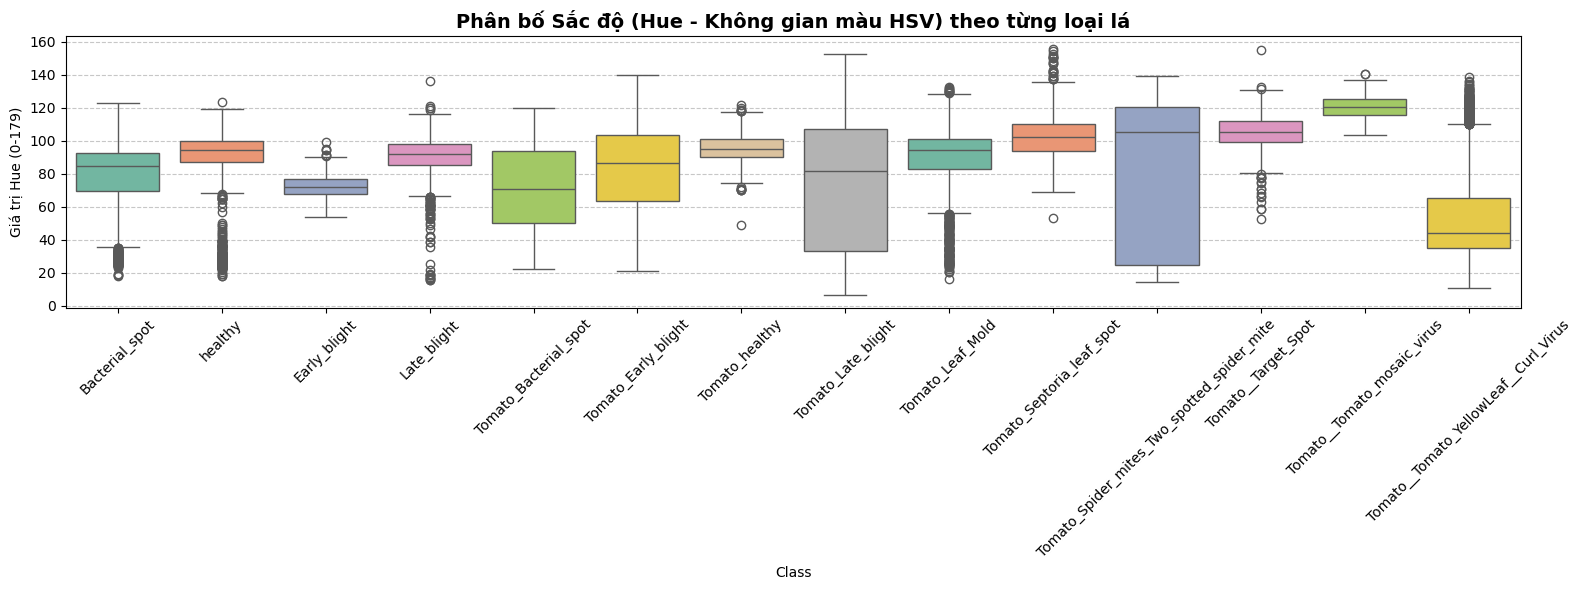

In [13]:
plt.figure(figsize=(16, 6))
sns.boxplot(data=df_eda2, x='Class', y='Hue', palette='Set2')
plt.title('Phân bố Sắc độ (Hue - Không gian màu HSV) theo từng loại lá', fontsize=14, fontweight='bold')
plt.ylabel('Giá trị Hue (0-179)')
plt.xticks(rotation=45) # Xoay chữ ở trục x để không bị đè lên nhau
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

C:\Users\Admin\AppData\Local\Temp\ipykernel_14648\4159837751.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_eda2, x='Class', y='Texture', palette='rocket')


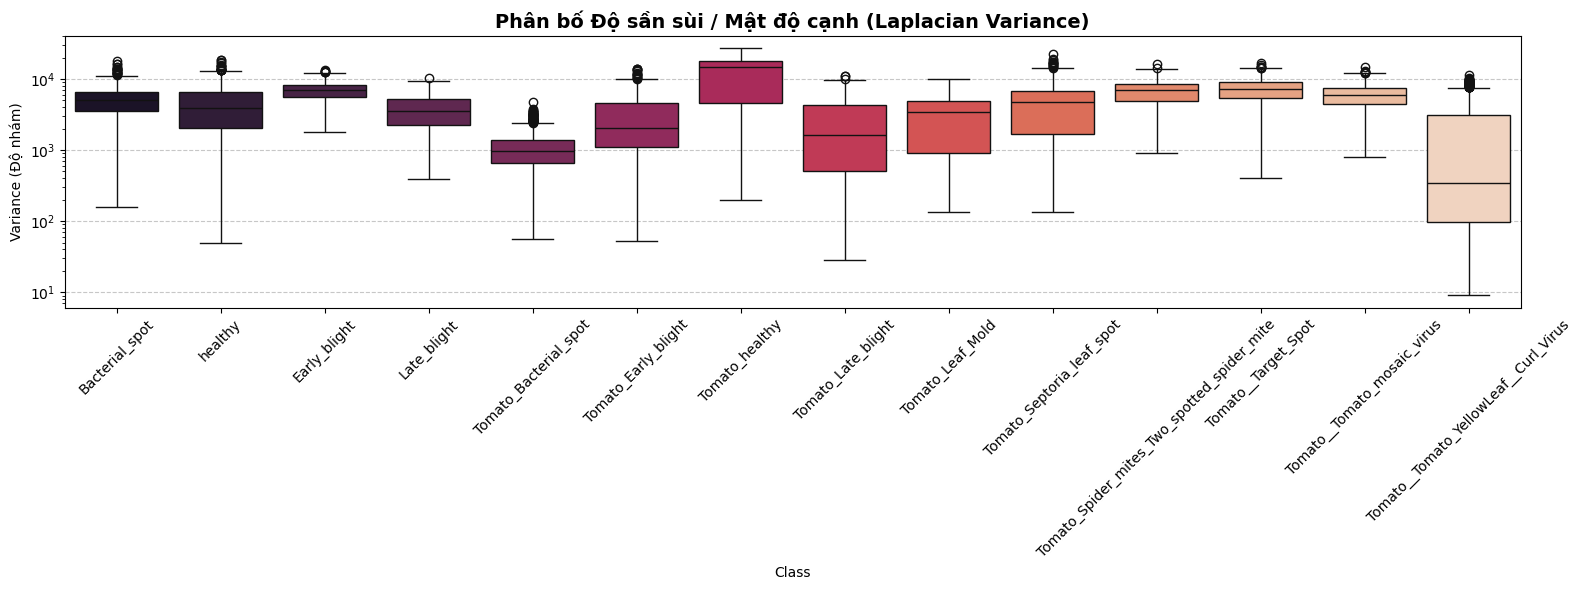

In [14]:
plt.figure(figsize=(16, 6))

# Vẽ biểu đồ Boxplot cho Texture
sns.boxplot(data=df_eda2, x='Class', y='Texture', palette='rocket')
plt.title('Phân bố Độ sần sùi / Mật độ cạnh (Laplacian Variance)', fontsize=14, fontweight='bold')
plt.ylabel('Variance (Độ nhám)')
plt.yscale('log') # Dùng thang đo Log vì variance có biên độ rất lớn
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

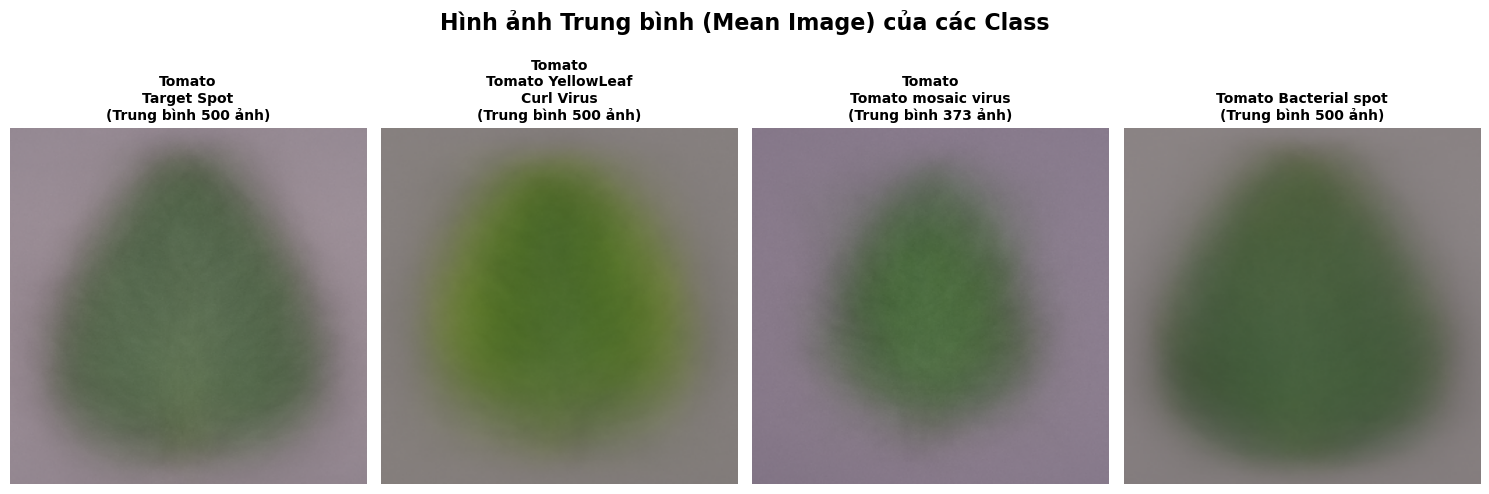

In [ ]:
# Chọn ngẫu nhiên 4 class để tính Mean Image (tránh làm tràn RAM nếu tính hết)
selected_classes = random.sample(classes, min(4, len(classes)))

plt.figure(figsize=(15, 5))

for i, c in enumerate(selected_classes):
    path = os.path.join(data_dir, c)
    img_files = glob.glob(os.path.join(path, '*.*'))
    

    w, h = 256, 256
    mean_img = np.zeros((h, w, 3), np.float32)
    valid_count = 0
    
    # Tính trung bình trên tối đa 500 ảnh mỗi class 
    sample_files = img_files[:500] 
    
    for img_path in sample_files:
        img = cv2.imread(img_path)
        if img is None: continue
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img_rgb = cv2.resize(img_rgb, (w, h))
        
        mean_img += img_rgb
        valid_count += 1
        
    # Chia trung bình
    mean_img = mean_img / valid_count
  
    mean_img = np.uint8(mean_img)
    
    plt.subplot(1, 4, i+1)
    plt.imshow(mean_img)
    short_title = c.replace('__', '\n').replace('_', ' ')
    plt.title(f"{short_title}\n(Trung bình {valid_count} ảnh)", fontsize=10, fontweight='bold')
    plt.axis('off')

plt.suptitle('Hình ảnh Trung bình (Mean Image) của các Class', fontsize=16, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()